<a href="https://colab.research.google.com/github/leandroclv/polars_udemy/blob/main/Visualizacao_join_empilhamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pl.read_csv(url)
df.head()

total_bill,tip,sex,smoker,day,time,size
f64,f64,str,str,str,str,i64
16.99,1.01,"""Female""","""No""","""Sun""","""Dinner""",2
10.34,1.66,"""Male""","""No""","""Sun""","""Dinner""",3
21.01,3.5,"""Male""","""No""","""Sun""","""Dinner""",3
23.68,3.31,"""Male""","""No""","""Sun""","""Dinner""",2
24.59,3.61,"""Female""","""No""","""Sun""","""Dinner""",4


In [5]:
#conversão para Pandas para a visualização
pdf = df.to_pandas()

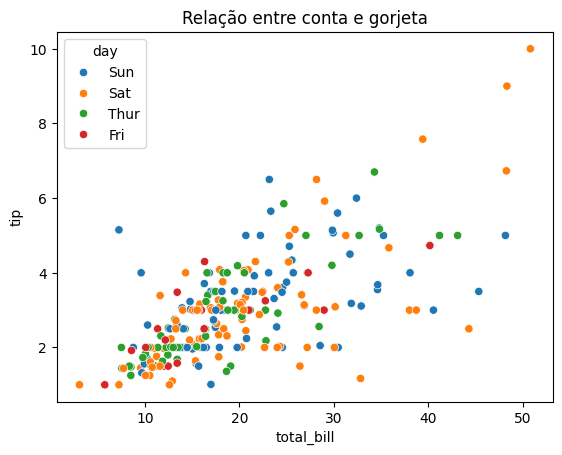

In [6]:
sns.scatterplot(data=pdf, x='total_bill', y='tip', hue = 'day')
plt.title('Relação entre conta e gorjeta')
plt.show()

In [7]:
#joins com Polars
#DataFrame.join(
#    other: DataFrame,
#    on: str | list[str] | None = None,
#    how: str= 'left' ,
#    suffix: str = '_right'
#)

In [8]:
clientes = pl.DataFrame({
    'id': [1,2,3],
    'nome': ['maria', 'paulo', 'rodrigo']
})

In [10]:
pedidos = pl.DataFrame({
    'pedido_id': [101,102,103],
    'cliente_id': [1,2,4],
    'valor': [100,150,200]
})

In [12]:
from numpy import inner
resultado = clientes.join(
    pedidos,
    left_on='id',
    right_on='cliente_id',
    how='inner'
)

In [13]:
resultado

id,nome,pedido_id,valor
i64,str,i64,i64
1,"""maria""",101,100
2,"""paulo""",102,150


In [14]:
produtos = pl.DataFrame({
    'produto': ['A', 'B', 'C'],
    'preco': [100,200,300]
})

In [15]:
quantidade = pl.DataFrame({
    'quantidade': [10,35,80]
})

In [16]:
resultado = produtos.join(quantidade, how='cross')
resultado

produto,preco,quantidade
str,i64,i64
"""A""",100,10
"""A""",100,35
"""A""",100,80
"""B""",200,10
"""B""",200,35
"""B""",200,80
"""C""",300,10
"""C""",300,35
"""C""",300,80


In [17]:
df1 = pl.DataFrame({
    'loja': ['A', 'A', 'B'],
    'mes': [1,2,1],
    'vendas': [100, 350, 280]
})

In [18]:
df2 = pl.DataFrame({
    'loja': ['A', 'B'],
    'mes': [1,1],
    'meta': [120, 160]
})

In [20]:
resultado = df1.join(df2, on=['loja', 'mes'], how='left')
display(resultado)

loja,mes,vendas,meta
str,i64,i64,i64
"""A""",1,100,120
"""A""",2,350,null
"""B""",1,280,160


In [21]:
df_a = pl.DataFrame({'id': [1,2], 'valor': [10,20]})
df_b = pl.DataFrame({'id': [3,4], 'valor': [30,40]})

In [22]:
concatenado = pl.concat([df_a,df_b])
display(concatenado)

id,valor
i64,i64
1,10
2,20
3,30
4,40


In [23]:
df_main = pl.DataFrame({'id': [1,2,3,4,5]})
df_filter = pl.DataFrame({'id': [2,4]})

In [24]:
resultado = df_main.filter(pl.col('id').is_in(df_filter['id']))
display(resultado)

/tmp/ipython-input-3354543619.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  resultado = df_main.filter(pl.col('id').is_in(df_filter['id']))


id
i64
2
4
